# Robbins-Monro SVM — Province vs Region comparison

This notebook tunes and evaluates the Robbins-Monro SVM optimizer under two
feature setups:

| Model | Categorical feature |
|-------|---------------------|
| **Original** | `Province / Territory` (13 one-hot columns) |
| **Region** | `region` (6 one-hot columns: Atlantic, Quebec, Ontario, Prairies, BC, Territories) |

All numeric features, transformations, CV folds, and optimizer hyperparameter
grids are identical between the two setups.

## 1. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

from cv_tuning import (
    prepare_train_test_data,
    prepare_train_test_data_region,
    CV_FOLDS,
)
from optimizers import (
    robbins_monro_svm,
    predict_rm,
    tune_optimizer_joint_cv,
    fit_best,
    RM_PARAM_GRID,
    print_eval_report,
    best_per_kernel,
    repeated_eval_comparison,
)

## 2. Load data — original and region variants

In [2]:
FILEPATH = '../data/ridings.csv'

data_orig   = prepare_train_test_data(filepath=FILEPATH)
data_region = prepare_train_test_data_region(filepath=FILEPATH)

print('Original  — X_train shape:', data_orig['X_train_proc'].shape)
print('Region    — X_train shape:', data_region['X_train_proc'].shape)

Original  — X_train shape: (273, 20)
Region    — X_train shape: (273, 14)


## 3. Hyperparameter search (10-fold CV)



In [3]:
from kernels import KERNEL_REGISTRY

n_kernels = sum(len(v['param_grid']) for v in KERNEL_REGISTRY.values())
print(f'RM param grid size : {len(RM_PARAM_GRID)} optimizer combos')
print(f'Kernel combos      : {n_kernels}')
print(f'Total configs      : {n_kernels * len(RM_PARAM_GRID)} × 10 folds')

RM param grid size : 36 optimizer combos
Kernel combos      : 42
Total configs      : 1512 × 10 folds


### 3a. Tune — Original (Province / Territory)

In [4]:
search_orig = tune_optimizer_joint_cv(
    robbins_monro_svm,
    data_orig['X_train_proc'],
    data_orig['y_train'],
    param_grid=RM_PARAM_GRID,
    verbose=True,
)

print('\nBest CV score (original):', round(search_orig['best_result']['mean_cv'], 4))
print('Best config  (original):', {
    k: v for k, v in search_orig['best_result'].items()
    if k not in {'mean_cv', 'std_cv', 'kernel_params'}
})

  linear    combos tested:   36  best_cv so far: 0.7913  [21s]
  rbf       combos tested:  216  best_cv so far: 0.8243  [127s]
  poly      combos tested: 1188  best_cv so far: 0.8351  [692s]
  sigmoid   combos tested: 1512  best_cv so far: 0.8351  [893s]

Best CV score (original): 0.8351
Best config  (original): {'kernel': 'poly', 'lambda_reg': 0.001, 'eta0': 0.01, 'decay': 0.01, 'n_epochs': 50}


### 3b. Tune — Region

In [5]:
search_region = tune_optimizer_joint_cv(
    robbins_monro_svm,
    data_region['X_train_proc'],
    data_region['y_train'],
    param_grid=RM_PARAM_GRID,
    verbose=True,
)

print('\nBest CV score (region):', round(search_region['best_result']['mean_cv'], 4))
print('Best config  (region):', {
    k: v for k, v in search_region['best_result'].items()
    if k not in {'mean_cv', 'std_cv', 'kernel_params'}
})

  linear    combos tested:   36  best_cv so far: 0.7874  [22s]
  rbf       combos tested:  216  best_cv so far: 0.8246  [136s]
  poly      combos tested: 1188  best_cv so far: 0.8246  [724s]
  sigmoid   combos tested: 1512  best_cv so far: 0.8246  [1015s]

Best CV score (region): 0.8246
Best config  (region): {'kernel': 'rbf', 'lambda_reg': 0.001, 'eta0': 0.1, 'decay': 0.1, 'n_epochs': 50}


## 4. Refit on full training set with best config

In [6]:
N_EPOCHS_FINAL = 150

fit_orig = fit_best(
    robbins_monro_svm,
    data_orig['X_train_proc'],  data_orig['y_train_svm'],
    data_orig['X_test_proc'],   data_orig['y_test_svm'],
    best_result=search_orig['best_result'],
    n_epochs_override=N_EPOCHS_FINAL,
)

fit_region = fit_best(
    robbins_monro_svm,
    data_region['X_train_proc'], data_region['y_train_svm'],
    data_region['X_test_proc'],  data_region['y_test_svm'],
    best_result=search_region['best_result'],
    n_epochs_override=N_EPOCHS_FINAL,
)

y_pred_orig   = predict_rm(fit_orig,   data_orig['X_test_proc'])
y_pred_region = predict_rm(fit_region, data_region['X_test_proc'])

acc_orig   = accuracy_score(data_orig['y_test'],   y_pred_orig)
acc_region = accuracy_score(data_region['y_test'], y_pred_region)

print(f'Test accuracy — Original : {acc_orig:.4f}')
print(f'Test accuracy — Region   : {acc_region:.4f}')

Test accuracy — Original : 0.8551
Test accuracy — Region   : 0.8696


## 5. Classification reports

In [7]:
print_eval_report(data_orig['y_test'], y_pred_orig,
                     model_name='RM SVM — Original (Province / Territory)')

=== RM SVM — Original (Province / Territory) ===
Test Accuracy : 0.8551

  Std    : 0.3520
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.94      0.87        35
           1       0.93      0.76      0.84        34

    accuracy                           0.86        69
   macro avg       0.87      0.85      0.85        69
weighted avg       0.87      0.86      0.85        69

--- Confusion Matrix ---
[[33  2]
 [ 8 26]]



In [8]:
print_eval_report(data_region['y_test'], y_pred_region,
                     model_name='RM SVM — Region')

=== RM SVM — Region ===
Test Accuracy : 0.8696

  Std    : 0.3368
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.86      0.87        35
           1       0.86      0.88      0.87        34

    accuracy                           0.87        69
   macro avg       0.87      0.87      0.87        69
weighted avg       0.87      0.87      0.87        69

--- Confusion Matrix ---
[[30  5]
 [ 4 30]]



## 6. Summary table

In [9]:
summary = pd.DataFrame({
    'Model':            ['Original (Province)', 'Region'],
    'Input features':   [
        data_orig['X_train_proc'].shape[1],
        data_region['X_train_proc'].shape[1],
    ],
    'Best CV score':    [
        round(search_orig['best_result']['mean_cv'],   4),
        round(search_region['best_result']['mean_cv'], 4),
    ],
    'Test accuracy':    [round(acc_orig, 4), round(acc_region, 4)],
    'Search time (s)':  [
        round(search_orig['fit_time_s'],   1),
        round(search_region['fit_time_s'], 1),
    ],
})

summary

,Model,Input features,Best CV score,Test accuracy,Search time (s)
0,Original (Province),20,0.8351,0.8551,893.4
1,Region,14,0.8246,0.8696,1014.9


e## 7. Kernel performance comparison

For each kernel, the bar shows the **best mean CV accuracy** (across all
optimizer hyperparameter combos) ± 1 std.

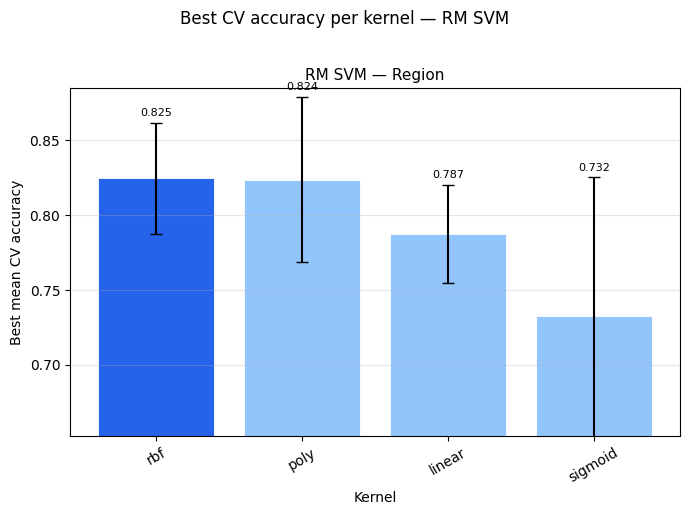

In [10]:
bpk_region = best_per_kernel(search_region['results_df'])

fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#2563eb' if i == 0 else '#93c5fd' for i in range(len(bpk_region))]
bars = ax.bar(bpk_region['kernel'], bpk_region['mean_cv'],
              yerr=bpk_region['std_cv'], capsize=4,
              color=colors, edgecolor='white', linewidth=0.6)
ax.set_title('RM SVM — Region', fontsize=11)
ax.set_xlabel('Kernel')
ax.set_ylabel('Best mean CV accuracy')
ax.set_ylim(
    max(0, bpk_region['mean_cv'].min() - 0.08),
    min(1, bpk_region['mean_cv'].max() + 0.06),
)
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
for bar, val, std in zip(bars, bpk_region['mean_cv'], bpk_region['std_cv']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 0.003,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=8,
    )

plt.suptitle('Best CV accuracy per kernel — RM SVM', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 8. Convergence plots

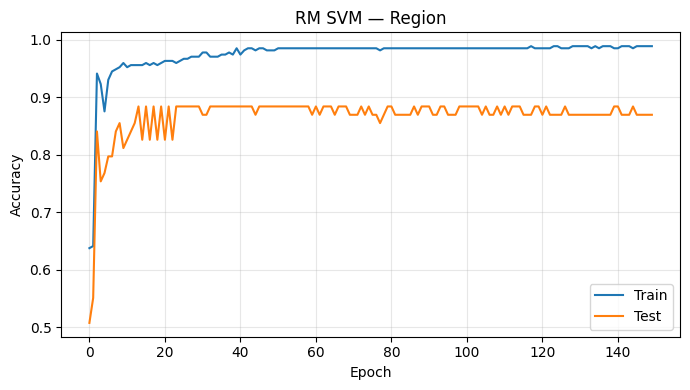

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(fit_region['train_acc_history'], label='Train')
ax.plot(fit_region['test_acc_history'],  label='Test')
ax.set_title('RM SVM — Region')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Repeated evaluation across random seeds

Re-evaluates both RM configurations (Original and Region) over 10 different
stratified train/test splits (seeds 0–9) to get robust accuracy estimates
and a fair comparison between the two feature setups.

In [14]:
experiments = [
    {
        "name": "RM — Original",
        "optimizer_fn": robbins_monro_svm,
        "best_result": search_orig["best_result"],
        "n_epochs_override": N_EPOCHS_FINAL,
    },
    {
        "name": "RM — Region",
        "optimizer_fn": robbins_monro_svm,
        "best_result": search_region["best_result"],
        "n_epochs_override": N_EPOCHS_FINAL,
    },
]

summary_rep, raw_rep = repeated_eval_comparison(
    experiments,
    filepath=FILEPATH,
    n_repetitions=10,
)
display(summary_rep)

,Optimizer,Mean Accuracy,Std Accuracy,Min,Max
#,,,,,
1,RM — Original,0.8174,±0.0439,0.7536,0.8841
2,RM — Region,0.8043,±0.0428,0.7391,0.8986


/var/folders/jq/j293cp2n5dnfj3z0h4pj7q0w0000gn/T/ipykernel_8749/2750900765.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=["RM — Original", "RM — Region"],


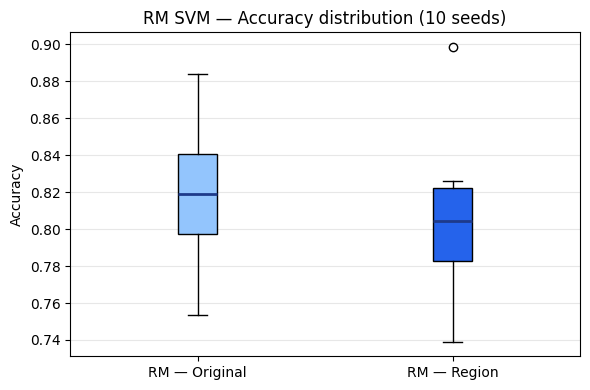

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

groups = [
    raw_rep[raw_rep["Optimizer"] == name]["Accuracy"].values
    for name in ["RM — Original", "RM — Region"]
]
bp = ax.boxplot(groups, labels=["RM — Original", "RM — Region"],
                patch_artist=True)
colors = ["#93c5fd", "#2563eb"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
for median in bp["medians"]:
    median.set_color("#1e3a8a")
    median.set_linewidth(2)

ax.set_ylabel("Accuracy")
ax.set_title("RM SVM — Accuracy distribution (10 seeds)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()